In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 5 5 5 5]
[0 1 2 2 2 2 2 2 2 2]


np.float64(485165195.4097903)

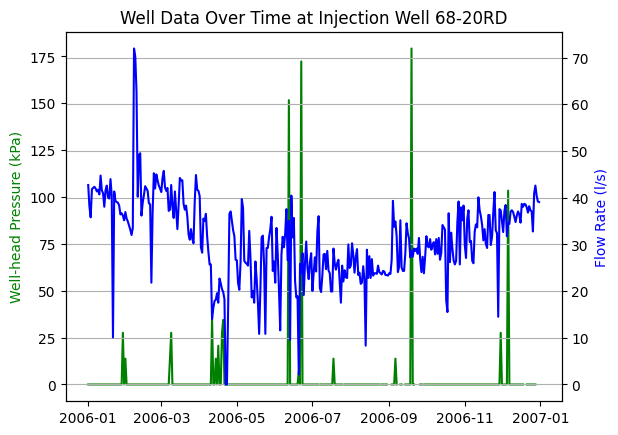

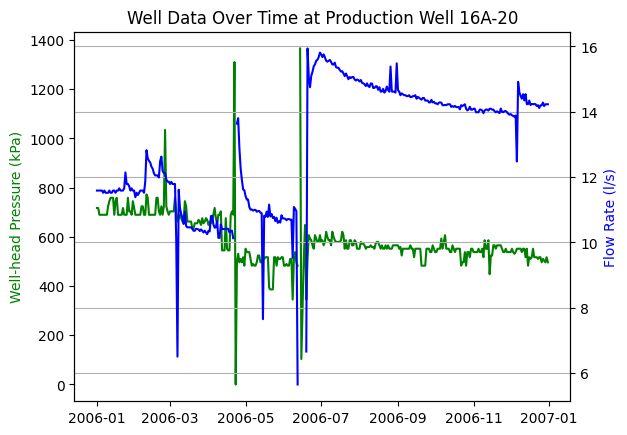

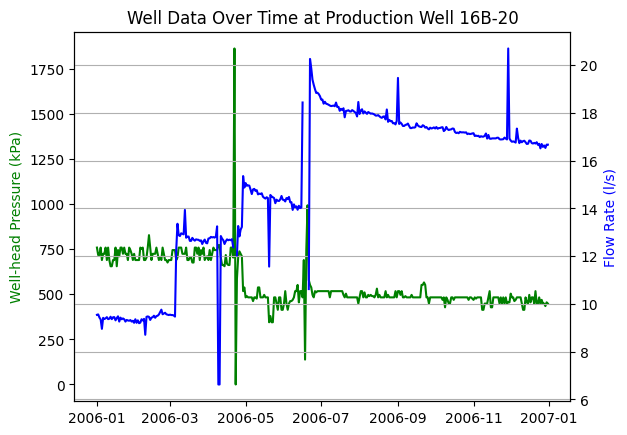

In [ ]:

# Load the CSV file, with header

# Get well-head pressure from the WHP_psig_ column and convert from psig to Pa
def psig_to_Pa(psig):
    return psig * 6894.76
# Convert CumInj_24hr from 10**6 lb/24h to m3/s
def megalb24h_to_m3s(lb24h):
    # Mlb = 10**6 lb = 453592.37 kg
    # 1 day = 86400 seconds
    # 1 m3 = 1000 kg
    return lb24h * 453592.37 / 86400 / 1000

def process_and_plot_data(data, injection):
    # Convert CumInj_24hr from 10**6 lb/24h to m3/s
    if injection:
        key = 'CumInj_24hr'
        title_ = 'Injection Well'
    else:
        key = 'CumMass_24hr'
        title_ = 'Production Well'
    # Find unique well names
    well_names = data['Wellname'].unique()
    # Convert the WHP_psig_ column to kPa
    data['WHP_Pa'] = psig_to_Pa(data['WHP_psig_'])
    data['CumMass_m3s'] = megalb24h_to_m3s(data[key])

    # First column is date in format  01-Jan-2006
    data['Date'] = pd.to_datetime(data['Date'], format='%d-%b-%Y')
    # Set the date as the index
    data.set_index('Date', inplace=True)
    for well in well_names:
        # Filter the data for the current well
        well_data = data[data['Wellname'] == well]
        # Plot pressure to right axis and injection rate to left axis
        fig, ax1 = plt.subplots()
        ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
        kpa = well_data['WHP_Pa'] / 1000  # convert to kPa
        ax1.plot(well_data.index, kpa, 'g-')
        lpers = well_data['CumMass_m3s'] * 1000  # convert to l/s
        ax2.plot(well_data.index, lpers, 'b-')  # plot flow rate on the right axis
        ax1.set_ylabel('Well-head Pressure (kPa)', color='g')
        ax2.set_ylabel('Flow Rate (l/s)', color='b')
        plt.title(f'Well Data Over Time at {title_} {well}')
        plt.grid()
        plt.show()

fns = ["Coso data/injection.csv", "Coso data/production.csv"]
for fn in fns:
    # Read the CSV file into a DataFrame
    # Use the first row as the header (header=0)
    # Use the first column as the index (index_col=0)
    # Parse dates in the first column (parse_dates=[0])
    # Set the date format to day-month-year (dayfirst=True)
    data = pd.read_csv(fn, header=0)

    process_and_plot_data(data, injection = "injection" in fn)


